## Load in Test Case & Run Power Flow

In [1]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation

In [70]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS


import andes

andes.config_logger(stream_level=30)

In [28]:
# import case file
case_path = andes.get_case(test_case_dir / "regf2_testbench.xlsx")
ss_ref = andes.load(case_path)

ss_ref.PFlow.run()

True

## Run TDS & Initial Results

In [55]:
ss = andes.load(case_path, setup=False)
ss.setup()
ss.config.warn_abnormal = 0
ss.PFlow.run()
ss.TDS.config.tf = 15
ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 1
ss.TDS.run()

True

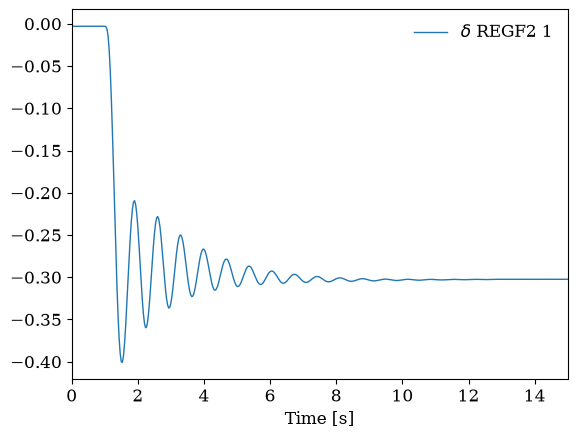

In [62]:
fig, ax = ss.TDS.plt.plot(ss.REGF2.delta)

## Metrics/Analysis

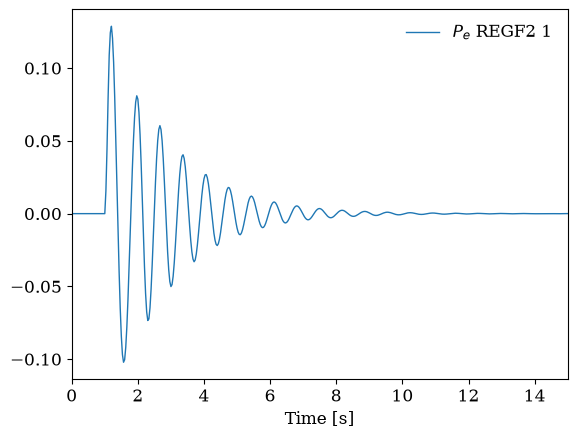

In [31]:
power_regf2_df = ss.TDS.get_timeseries(ss.REGF2.Pe)
fig, ax = ss.TDS.plt.plot(ss.REGF2.Pe)

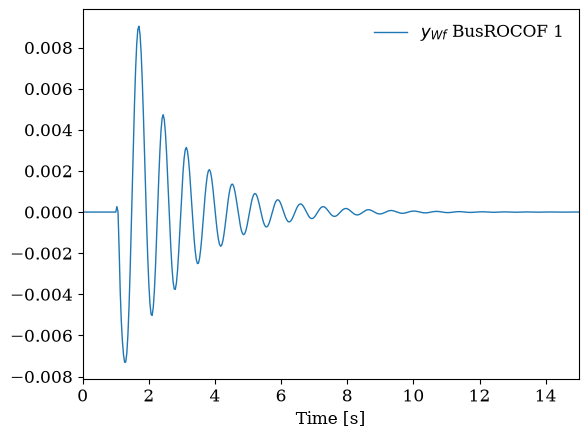

In [33]:
rocof_pu = ss.TDS.get_timeseries(ss.BusROCOF.Wf_y)
fig, ax = ss.TDS.plt.plot(ss.BusROCOF.Wf_y)

In [34]:
run = 0

# conversion
S_n = ss.REGF2.get("Sn", 1)
f_0 = 60 #Hz

Tr = ss.REGF2.get("Tr", 1) # nominal
peak_inertial_power = np.max(power_regf2_df) * S_n  # nominal
max_rocof = np.max(rocof_pu) * f_0  # nominal
freq_nadir = np.min(ss.TDS.get_timeseries(ss.BusROCOF.f)) * f_0  # nominal

p_avail = ss.REGF2.get("Pmax", 1) # pu
p_ref = ss.PV.get("p0", 1) # pu


### H Calculation

In [68]:
deltaP = power_regf2_df.subtract(p_ref)
deltaF = ss.TDS.get_timeseries(ss.BusROCOF.f) - 1

tds_df = pd.concat([deltaP, deltaF, rocof_pu], axis=1)
tds_df.columns = ["Delta P (pu)", "Delta F (pu)", "RoCoF (pu)"]

tds_df

,Delta P (pu),Delta F (pu),RoCoF (pu)
0.000000,0.000000,0.000000e+00,0.000000e+00
0.000100,0.000000,0.000000e+00,0.000000e+00
0.033233,0.000000,0.000000e+00,0.000000e+00
0.033333,0.000000,0.000000e+00,0.000000e+00
0.033433,0.000000,0.000000e+00,0.000000e+00
...,...,...,...
14.966667,0.000032,3.483297e-07,6.383389e-07
14.966767,0.000032,3.481444e-07,6.358491e-07
14.966867,0.000032,3.479588e-07,6.339954e-07
14.999900,0.000038,2.730582e-07,-1.881241e-07


In [100]:
window = 18 # ANDES step time = 1/30s, so to get a 200ms window is 6 steps
#slope = tds_df['Delta P (pu)'].rolling(window).cov(tds_df['RoCoF (pu)']) / tds_df['RoCoF (pu)'].rolling(window).var()
#H_t = -slope / 2

X = sm.add_constant(tds_df[['RoCoF (pu)', 'Delta F (pu)']])  # add Δf as 2nd predictor
model = RollingOLS(tds_df['Delta P (pu)'], X, window=window)
res = model.fit()

H_t = -res.params['RoCoF (pu)'] / 2 
D_t = res.params['Delta F (pu)']

tds_df.loc[:,"H (s)"] = H_t
tds_df.loc[:,"D"] = D_t

tds_df

,Delta P (pu),Delta F (pu),RoCoF (pu),H (s),D
0.000000,0.000000,0.000000e+00,0.000000e+00,NaN,NaN
0.000100,0.000000,0.000000e+00,0.000000e+00,NaN,NaN
0.033233,0.000000,0.000000e+00,0.000000e+00,NaN,NaN
0.033333,0.000000,0.000000e+00,0.000000e+00,NaN,NaN
0.033433,0.000000,0.000000e+00,0.000000e+00,NaN,NaN
...,...,...,...,...,...
14.966667,0.000032,3.483297e-07,6.383389e-07,9.653641,132.641909
14.966767,0.000032,3.481444e-07,6.358491e-07,9.665178,132.468418
14.966867,0.000032,3.479588e-07,6.339954e-07,9.675912,132.035959
14.999900,0.000038,2.730582e-07,-1.881241e-07,9.691086,131.663975


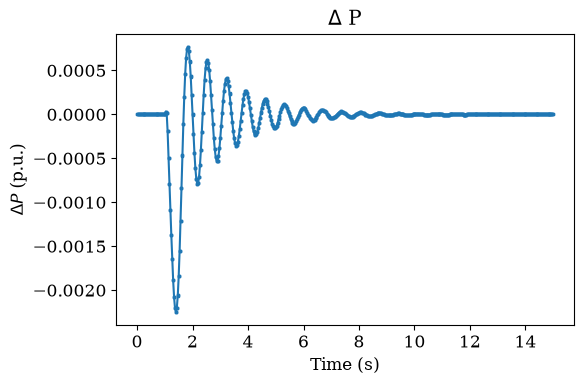

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.set_title(f"$\Delta$ P")
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"$\Delta P$ (p.u.)")

# plot actual
ax.plot(deltaP.index, deltaP, "s-", color="tab:blue",
        markersize=1.8)

plt.tight_layout()

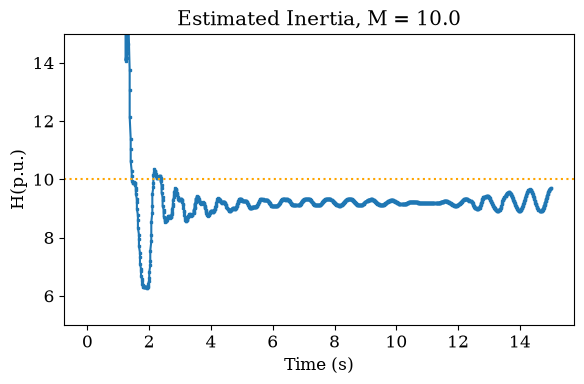

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

H_gfm = ss.REGF2.get("mf", 1) * 0.5

ax.set_title(f"Estimated Inertia, H = {H_gfm}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("H(p.u.)")

# plot actual
ax.plot(H_t.index, H_t, "s-", color="tab:blue",
        markersize=1.8)

plt.axline((0, H_gfm), slope=0, color="orange", linestyle=":", label="Point & Slope")

#plt.xlim(0, 8)
plt.ylim(5, 15)
plt.tight_layout()